In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

In [ ]:
def unpair_df(data):
    """
    Unpairs columns in the DataFrame that start with 'l1' or 'l2' by renaming them to 'l'
    and concatenating the resulting DataFrames vertically.

    Parameters:
    data (pd.DataFrame): The original DataFrame containing columns to be unpaired.

    Returns:
    pd.DataFrame: A new DataFrame with columns starting with 'l1' and 'l2' renamed to 'l',
                  and the DataFrame length doubled by concatenating the modified DataFrames.
    """
    l1_columns = [col for col in data.columns if 'l1' in col]
    l2_columns = [col for col in data.columns if 'l2' in col]
    other_columns = [col for col in data.columns if not ('l1' in col or 'l2' in col)]

    # Create a copy of the DataFrame with 'l1' and 'l2' columns renamed to 'l'
    data_l1 = data[other_columns + l1_columns].copy()
    data_l2 = data[other_columns + l2_columns].copy()

    data_l1.rename(columns={col: col.replace('l1', 'm_lx', 1) for col in l1_columns}, inplace=True)
    data_l2.rename(columns={col: col.replace('l2', 'm_lx', 1) for col in l2_columns}, inplace=True)

    # Concatenate the DataFrames vertically
    new_data = pd.concat([data_l1, data_l2], ignore_index=True)
    return new_data

def repair_df(data):
    """
    Pairs columns in the DataFrame that contain 'm_lx' by renaming them back to 'l1' and 'l2',
    and merges rows based on shared columns, resulting in the original DataFrame format.

    Parameters:
    data (pd.DataFrame): The DataFrame output from `unpair_df` function with doubled rows.

    Returns:
    pd.DataFrame: A DataFrame where columns containing 'm_lx' are renamed back to 'l1' and 'l2',
                  and rows are merged back to their original format with shared columns appearing only once.
    """
    # Split the data into two halves
    midpoint = len(data) // 2
    data_l1 = data.iloc[:midpoint].copy()
    data_l2 = data.iloc[midpoint:].copy()

    # Identify shared columns (not containing 'm_lx')
    shared_columns = [col for col in data.columns if 'm_lx' not in col]

    # Rename columns by replacing 'm_lx' with 'l1' in data_l1 and 'l2' in data_l2
    data_l1.rename(columns={col: col.replace('m_lx', 'l1') for col in data_l1.columns if 'm_lx' in col}, inplace=True)
    data_l2.rename(columns={col: col.replace('m_lx', 'l2') for col in data_l2.columns if 'm_lx' in col}, inplace=True)

    # Concatenate the two halves on columns, only including shared columns once
    paired_data = pd.concat(
        [data_l1.reset_index(drop=True)[shared_columns + [col for col in data_l1.columns if col not in shared_columns]],
         data_l2.reset_index(drop=True)[[col for col in data_l2.columns if col not in shared_columns]]],
        axis=1
    )

    return paired_data

def filter_columns(df, key_phrases):
    """
    Filters out columns that contain any of the key phrases in their names.

    Parameters:
    df (pd.DataFrame): The dataframe to filter.
    key_phrases (list): A list of key phrases to filter out.

    Returns:
    list: A list of column names that do not contain any of the key phrases.
    """
    filtered_columns = [col for col in df.columns if not any(phrase in col for phrase in key_phrases)]
    return filtered_columns


In [31]:
data = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_root/data_100k_zeederiv.parquet')
mask = (data['ll_m_Truth'] > 50) & (data['ll_m_Truth'] < 130)
data = data[mask] 

no


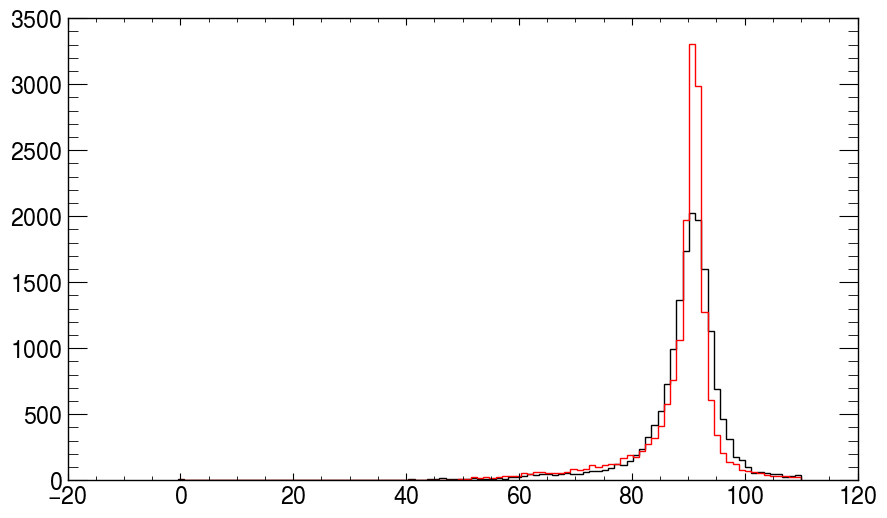

In [32]:
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(data['ll_m'], bins=100,range=(-0.5,110), histtype='step', color='black', label='Data')
ax.hist(data['ll_m_Truth'], bins=100,range=(-0.5,110), histtype='step', color='red', label='Truth')
print('no')

In [33]:
for col in data.columns:
    print(col)

Btag60_N_j
Btag70_N_j
Btag77_N_j
Btag85_N_j
Btag_N_j
Central_N_j
Central_pT_jj
EventInfo.PVx
EventInfo.PVy
EventInfo.PVz
EventInfo.actualIntPerXing
EventInfo.averageIntPerXing
EventInfo.mu
MET_Dphi_ForwardJets
MET_Dphi_SoftJets
MET_Dphi_Zy
MET_Dphi_j1
MET_Dphi_l1
MET_Dphi_l2
MET_Dphi_ll
MET_Dphi_ph
MET_RefEle
MET_RefGamma
MET_RefJets
MET_RefMuons
MET_met_PVSoftTrk
MET_met_SoftClus
MET_met_TST
MET_met_Truth
MET_phi_PVSoftTrk
MET_phi_TST
MET_sig_TST
MET_sig_Truth
MET_sumet_TST
MET_sumet_Truth
MET_x_TST
MET_y_TST
ML_l1_eta
ML_l1_m
ML_l1_phi
ML_l1_pt
ML_l2_eta
ML_l2_m
ML_l2_phi
ML_l2_pt
ML_l3_eta
ML_l3_m
ML_l3_phi
ML_l3_pt
ML_l4_eta
ML_l4_m
ML_l4_phi
ML_l4_pt
VBF_BDTG
VBF_DRmin_y_j
VBF_Dphi_Zy_jj
VBF_Dphi_Zy_jj_FullRange
VBF_Dy_j_j
VBF_N_j
VBF_Zepp
VBF_eta_j1
VBF_eta_j2
VBF_m_jj
VBF_mass_j1
VBF_mass_j2
VBF_pT_j1
VBF_pT_j2
VBF_pT_jj
VBF_pTt_Zy
VBF_passFJVT_j1
VBF_passFJVT_j2
VBF_phi_j1
VBF_phi_j2
Z_truth_mass
Zy_Dphi_j1
etaTruthL0
etaTruthL1
etaTruthY
j1_eta_Truth
j1_m_Truth
j1_phi_Truth
j1

In [34]:
def filter_columns(df, key_phrases):
    """
    Filters out columns that contain any of the key phrases in their names.

    Parameters:
    df (pd.DataFrame): The dataframe to filter.
    key_phrases (list): A list of key phrases to filter out.

    Returns:
    list: A list of column names that do not contain any of the key phrases.
    """
    filtered_columns = [col for col in df.columns if not any(phrase in col for phrase in key_phrases)]
    return filtered_columns


In [35]:
def unpair_df(data):
    l1_columns = [col for col in data.columns if 'l1' in col]
    l2_columns = [col for col in data.columns if 'l2' in col]
    other_columns = [col for col in data.columns if not ('l1' in col or 'l2' in col)]

    # Create a copy of the DataFrame with 'l1' and 'l2' columns renamed to 'l'
    data_l1 = data[other_columns + l1_columns].copy()
    data_l2 = data[other_columns + l2_columns].copy()

    data_l1.rename(columns={col: col.replace('l1', 'l', 1) for col in l1_columns}, inplace=True)
    data_l2.rename(columns={col: col.replace('l2', 'l', 1) for col in l2_columns}, inplace=True)

    # Concatenate the DataFrames vertically
    new_data = pd.concat([data_l1, data_l2], ignore_index=True)
    return new_data

In [36]:
print(data.shape)
unpaired_data = unpair_df(data)
print(unpaired_data.shape)
print(*unpaired_data.columns)
key_phrases = ['truth', 'ph', 'Truth', 'mc']
param_list = filter_columns(unpaired_data, key_phrases)
print(param_list)

(17194, 440)
(34388, 367)
Btag60_N_j Btag70_N_j Btag77_N_j Btag85_N_j Btag_N_j Central_N_j Central_pT_jj EventInfo.PVx EventInfo.PVy EventInfo.PVz EventInfo.actualIntPerXing EventInfo.averageIntPerXing EventInfo.mu MET_Dphi_ForwardJets MET_Dphi_SoftJets MET_Dphi_Zy MET_Dphi_j1 MET_Dphi_ll MET_Dphi_ph MET_RefEle MET_RefGamma MET_RefJets MET_RefMuons MET_met_PVSoftTrk MET_met_SoftClus MET_met_TST MET_met_Truth MET_phi_PVSoftTrk MET_phi_TST MET_sig_TST MET_sig_Truth MET_sumet_TST MET_sumet_Truth MET_x_TST MET_y_TST ML_l3_eta ML_l3_m ML_l3_phi ML_l3_pt ML_l4_eta ML_l4_m ML_l4_phi ML_l4_pt VBF_BDTG VBF_DRmin_y_j VBF_Dphi_Zy_jj VBF_Dphi_Zy_jj_FullRange VBF_Dy_j_j VBF_N_j VBF_Zepp VBF_eta_j1 VBF_eta_j2 VBF_m_jj VBF_mass_j1 VBF_mass_j2 VBF_pT_j1 VBF_pT_j2 VBF_pT_jj VBF_pTt_Zy VBF_passFJVT_j1 VBF_passFJVT_j2 VBF_phi_j1 VBF_phi_j2 Z_truth_mass Zy_Dphi_j1 etaTruthL0 etaTruthL1 etaTruthY j1_eta_Truth j1_m_Truth j1_phi_Truth j1_pt_Truth j2_eta_Truth j2_m_Truth j2_phi_Truth j2_pt_Truth ll_dR_fsr ll_

In [37]:
target = unpaired_data['l_pt_Truth']
features = unpaired_data


 * Initiating LGBMTuner.fit
     . Settings:
     .. Trying 30 trials
     .. Evaluation metric: mae 
     .. Study direction: minimize mae

     . Trial number: 0 finished
     .. Optimization score (lower-better): mae: 3.0523301238155978
 ...........................................................................
     . Trial number: 1 finished
     .. Optimization score (lower-better): mae: 3.2585993035505876
 ...........................................................................
     . Trial number: 2 finished
     .. Optimization score (lower-better): mae: 3.0007208832955223
 ...........................................................................
     . Trial number: 3 finished
     .. Optimization score (lower-better): mae: 3.3060533714273483
 ...........................................................................
     . Trial number: 4 finished
     .. Optimization score (lower-better): mae: 3.143406286133721
 .......................................................

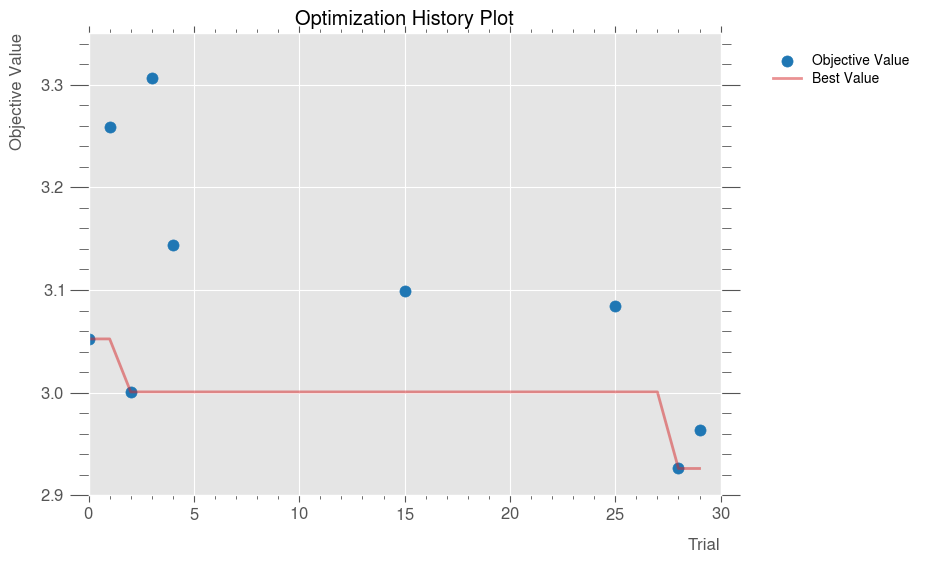

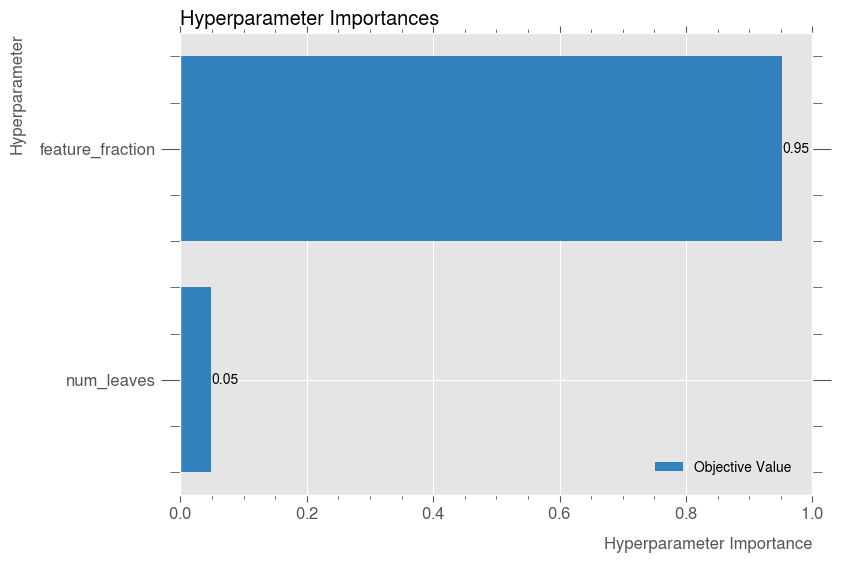

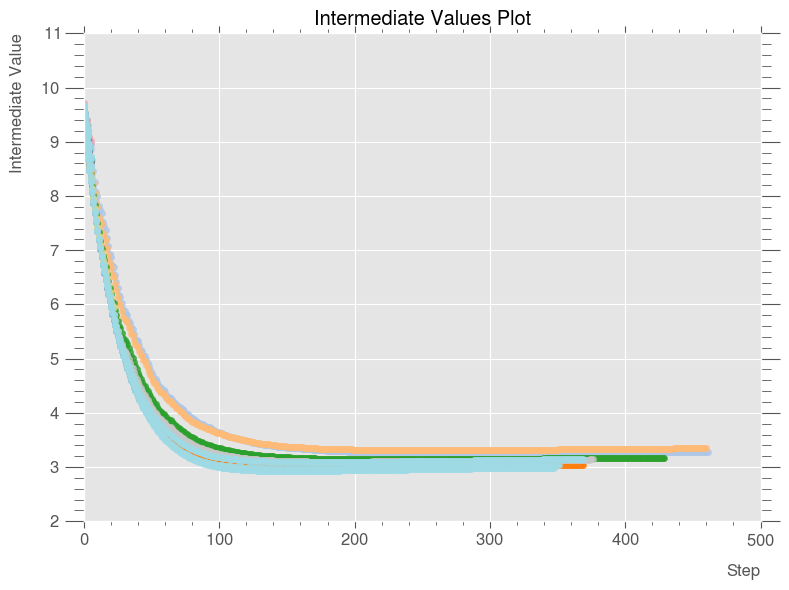

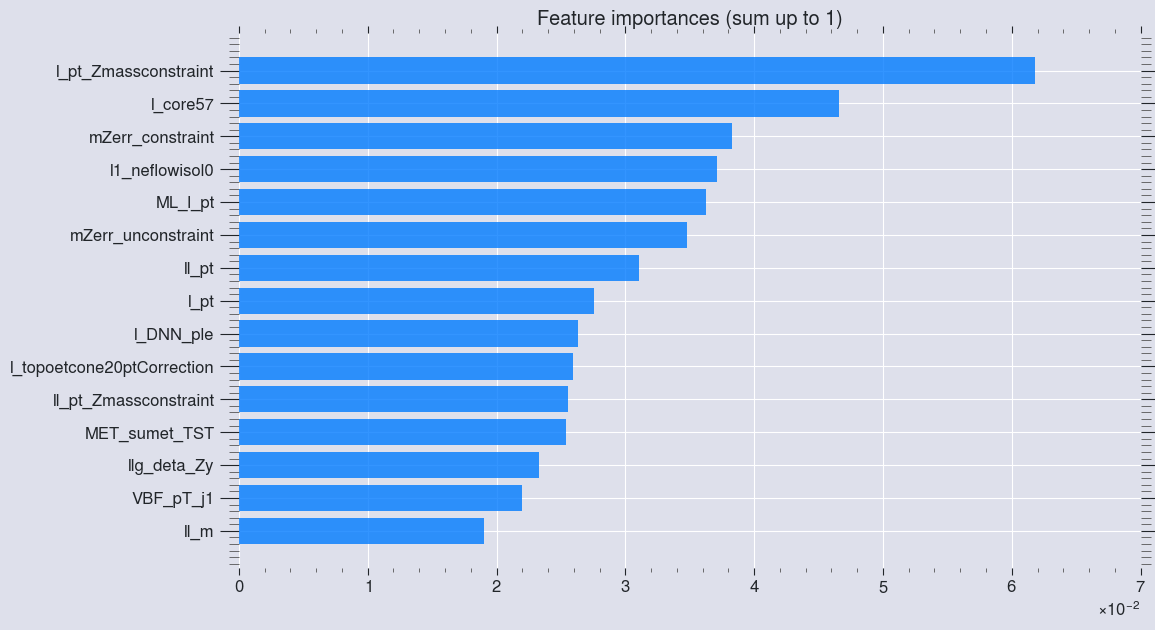


     . Optuna hyperparameters optimization finished
     .. Best trial number:28    |     mae:           2.9261205560094408
 ---------------------------------------------------------------------------

Time elapsed for fit execution: 1 min 42.499 sec

   - Fitting optimized model with the following params:
learning_rate                    : 0.03
num_leaves                       : 204
feature_fraction                 : 0.9836415643778214
bagging_fraction                 : 0.9
verbosity                        : -1
random_state                     : 42
device_type                      : cpu
objective                        : regression
metric                           : l1
num_threads                      : 46
lambda_l1                        : 0.5
num_iterations                   : 148


In [38]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Define the model
tuner = RapidGBMTuner(metric='mae', trials=30, refit=True, verbosity=1, visualization=True, seed=414243)
tuner.fit(X_train[param_list], y_train)

tuner.fit_optimized(X_train[param_list].to_numpy(), y_train.squeeze().to_numpy())

In [39]:
prediction = tuner.predict(X_test[param_list])
plt.rcdefaults()
hep.style.use([hep.style.ATLAS])

no


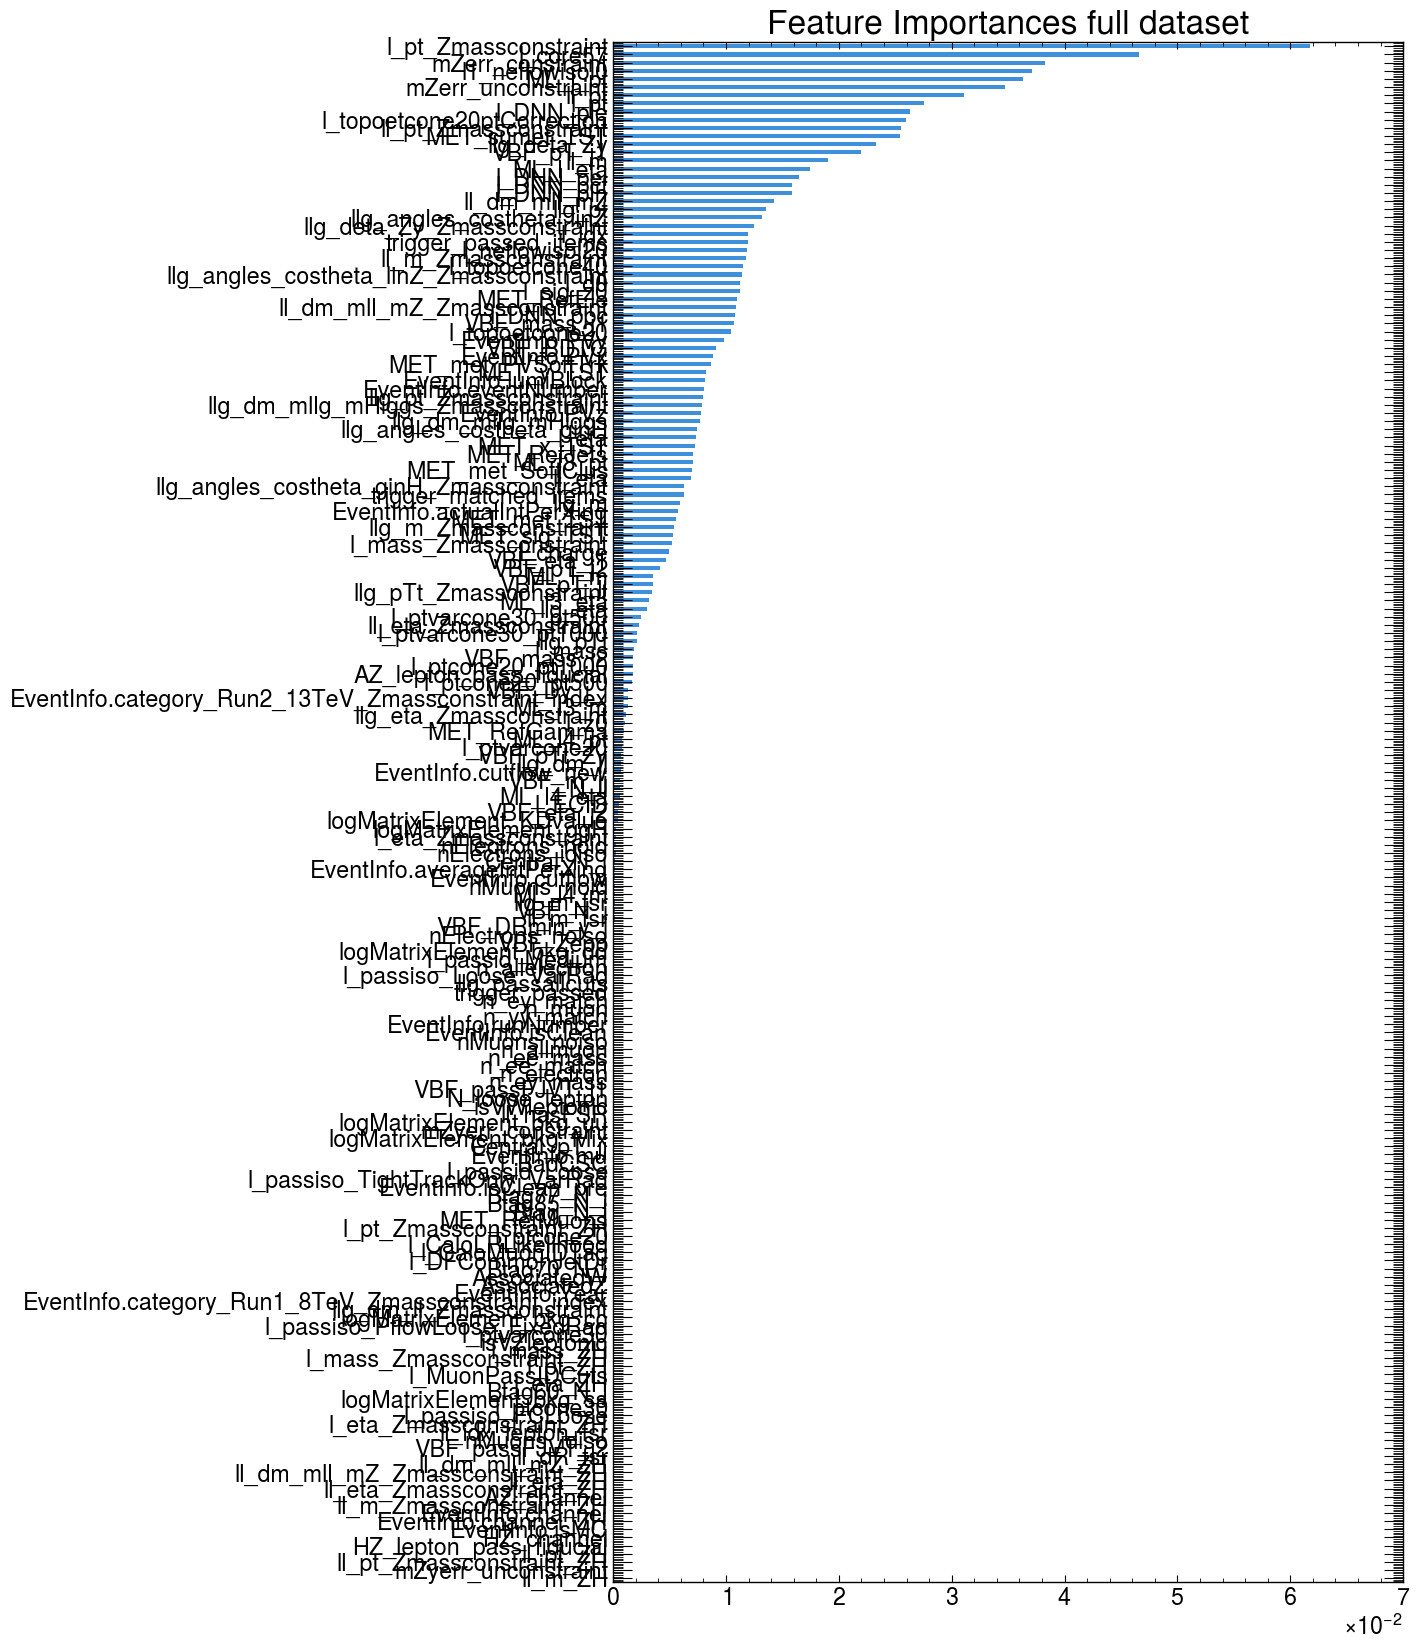

In [40]:
fig, ax = plt.subplots(figsize=(10, 20))
ax.set_title('Feature Importances full dataset')
tuner.feature_importances.sort_values().plot(ax=ax,kind='barh')
# ax.set_xticklabels(tuner.feature_importances.sort_values().index, rotation=45)
print('no')

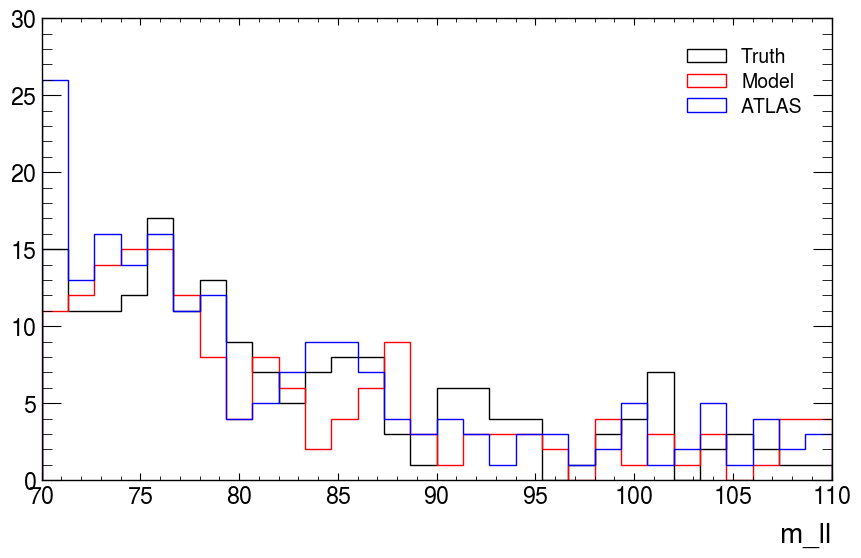

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(y_test, bins=30, range=(70, 110), histtype='step', label='Truth', color='black')
ax.hist(prediction, bins=30, range=(70, 110), histtype='step', label='Model', color='red')
ax.hist(X_test['l_pt'], bins=30, range=(70, 110), histtype='step', label='ATLAS', color='blue')
ax.set_xlabel('m_ll')
ax.legend()

In [42]:
print(len(data[( (data['l1_truthOrigin'] == 13 ) & (data['l2_truthOrigin'] == 13) ) ]))
print(len(data))
print(data['l1_truthOrigin'].value_counts())
print(data['l2_truthOrigin'].value_counts())
print(data['l1_truthType'].value_counts())
print(data['l2_truthType'].value_counts())
print(unpaired_data['l_truthType'].value_counts())

16410
17194
l1_truthOrigin
13.0    16951
5.0       197
0.0        44
7.0         1
26.0        1
Name: count, dtype: int64
l2_truthOrigin
13.0    16608
5.0       310
0.0       268
42.0        2
25.0        2
35.0        1
26.0        1
6.0         1
40.0        1
Name: count, dtype: int64
l1_truthType
2.0     16950
4.0       198
17.0       23
0.0        21
6.0         1
3.0         1
Name: count, dtype: int64
l2_truthType
2.0     16607
4.0       311
17.0      243
0.0        25
16.0        2
3.0         2
6.0         1
7.0         1
8.0         1
15.0        1
Name: count, dtype: int64
l_truthType
2.0     33557
4.0       509
17.0      266
0.0        46
3.0         3
6.0         2
16.0        2
7.0         1
8.0         1
15.0        1
Name: count, dtype: int64


In [43]:
# lets see what particles we have
print(data['l1_truthType'][data['EventInfo.cutflow']==10].value_counts())
print(data['l2_truthType'][data['EventInfo.cutflow']==10].value_counts())

l1_truthType
2.0     1900
4.0       73
17.0      23
0.0       21
3.0        1
Name: count, dtype: int64
l2_truthType
2.0     1615
17.0     243
4.0      130
0.0       25
16.0       2
7.0        1
8.0        1
15.0       1
Name: count, dtype: int64
